In [1]:
# ==============================================================================
# Cellula Technologies ML Track - Tasks 1 & 2
# End-to-End Fare Prediction Pipeline Architecture
# Engineer: Nagham
# ==============================================================================

import os
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]

print('✅ All essential libraries loaded successfully!')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\VICTUS\anaconda3\Lib\site-p

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\VICTUS\anaconda3\Lib\site-p

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\VICTUS\anaconda3\Lib\site-p

AttributeError: _ARRAY_API not found

✅ All essential libraries loaded successfully!


In [2]:
DATA_PATH = 'dataset.csv'

def load_and_sanitize_data(data_path: str) -> pd.DataFrame:
    if not os.path.exists(data_path):
        print(f"⚠️ File '{data_path}' not found. Generating synthetic benchmark dataset...")
        np.random.seed(42)
        n = 1000
        df = pd.DataFrame({
            'Passenger Count': np.random.choice([1, 2, 3, 4, 5, np.nan], n),
            'Fare-Amount': np.random.uniform(5.0, 100.0, n),
            'Car_Condition': np.random.choice(['Good', 'Excellent', 'Fair', np.nan], n),
            'traffic_conditions': np.random.choice(['Low', 'Medium', 'High'], n),
            'Hour': np.random.randint(0, 24, n),
            'Weather': np.random.choice(['Sunny', 'Rainy', 'Snowy'], n),
            'Distance': np.random.uniform(0.5, 30.0, n),
            'JFK Dist': np.random.uniform(5.0, 25.0, n)
        })
    else:
        df = pd.read_csv(data_path, encoding='utf-8-sig')

    df.columns = df.columns.str.strip()
    column_mapping = {}
    for col in df.columns:
        c = col.lower().replace('_', ' ').replace('-', ' ').strip()
        if 'passenger' in c: column_mapping[col] = 'Passenger_Count'
        elif 'fare' in c: column_mapping[col] = 'Fare_Amount'
        elif 'car' in c: column_mapping[col] = 'Car_Condition'
        elif 'traffic' in c: column_mapping[col] = 'Traffic_Conditions'
        elif 'hour' in c: column_mapping[col] = 'Hour'
        elif 'weather' in c: column_mapping[col] = 'Weather'
        elif 'jfk' in c: column_mapping[col] = 'JFK_Dist'
        elif 'ewr' in c: column_mapping[col] = 'EWR_Dist'
        elif 'lga' in c: column_mapping[col] = 'LGA_Dist'
        elif 'sol' in c: column_mapping[col] = 'SOL_Dist'
        elif 'dist' in c or 'distance' in c: column_mapping[col] = 'Distance'

    df = df.rename(columns=column_mapping)
    df = df.loc[:, ~df.columns.duplicated()]
    
    initial_count = len(df)
    df.drop_duplicates(inplace=True)
    print(f"📊 Dataset Loaded: {len(df)} rows ({initial_count - len(df)} duplicate rows removed).")
    return df

df = load_and_sanitize_data(DATA_PATH)
df.head()

⚠️ File 'dataset.csv' not found. Generating synthetic benchmark dataset...
📊 Dataset Loaded: 1000 rows (0 duplicate rows removed).


,Passenger_Count,Fare_Amount,Car_Condition,Traffic_Conditions,Hour,Weather,Distance,JFK_Dist
0,4.0,14.669335,Excellent,High,3,Sunny,9.572129,12.982522
1,5.0,19.521618,nan,Medium,8,Rainy,15.015607,9.845143
2,3.0,28.365984,Good,High,21,Rainy,23.997001,9.069760
3,5.0,20.264730,nan,High,23,Sunny,7.359969,24.091077
4,5.0,22.723867,Excellent,High,22,Snowy,7.167979,23.370432


In [3]:
print('--- Missing Values Ratio (%) ---')
print((df.isnull().mean() * 100).round(2))

print('\n--- Numerical Columns Overview ---')
display(df.describe())

--- Missing Values Ratio (%) ---
Passenger_Count       15.5
Fare_Amount            0.0
Car_Condition          0.0
Traffic_Conditions     0.0
Hour                   0.0
Weather                0.0
Distance               0.0
JFK_Dist               0.0
dtype: float64

--- Numerical Columns Overview ---


,Passenger_Count,Fare_Amount,Hour,Distance,JFK_Dist
count,845.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,2.990533,52.525415,11.86300,14.951440,14.697835
std,1.439920,27.602858,6.97143,8.431399,5.902742
min,1.000000,5.440042,0.00000,0.505503,5.012550
25%,2.000000,27.550638,6.00000,7.733499,9.456561
50%,3.000000,53.216210,12.00000,14.735598,14.671244
75%,4.000000,75.643688,18.00000,22.257063,19.689047
max,5.000000,99.944304,23.00000,29.926785,24.996985


In [4]:
target_col = 'Fare_Amount'
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"✂️ Training Features Shape : {X_train.shape}")
print(f"✂️ Testing Features Shape  : {X_test.shape}")

✂️ Training Features Shape : (800, 7)
✂️ Testing Features Shape  : (200, 7)


In [5]:
num_cols = [c for c in ['Distance', 'JFK_Dist', 'EWR_Dist', 'LGA_Dist', 'SOL_Dist', 'Hour', 'Passenger_Count'] if c in X_train.columns]
cat_cols = [c for c in ['Car_Condition', 'Traffic_Conditions', 'Weather'] if c in X_train.columns]

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

print('🛠️ Data Preprocessing Pipeline Constructed Successfully!')

🛠️ Data Preprocessing Pipeline Constructed Successfully!


In [7]:
# ------------------------------------------------------------------------------
# Cell 6: Robust Model Pipeline & Hyperparameter Tuning
# ------------------------------------------------------------------------------

# استخدام SelectFromModel مع تحديد threshold يضمن عدم حذف جميع الخصائص
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        LassoCV(cv=5, random_state=42, max_iter=5000), 
        threshold='mean'  # احتفاظ بالخصائص التي أعلى من المتوسط أو استخدام 'median'
    )),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5],
    'regressor__max_features': ['sqrt', 'log2']
}

print('⚙️ Running RandomizedSearchCV Dynamic Tuning...')

search = RandomizedSearchCV(
    full_pipeline,
    param_distributions=param_grid,
    n_iter=6,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

# في حال كان Lasso حاداً جداً وقام بحذف كل الخصائص، نستخدم النسخة الاحتياطية تلقائياً
try:
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
except ValueError:
    print("⚠️ LassoCV removed all features. Falling back to direct RandomForest Pipeline...")
    
    # بايبلاين بدون LassoCV كخطوة حماية
    fallback_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
    ])
    
    search = RandomizedSearchCV(
        fallback_pipeline,
        param_distributions=param_grid,
        n_iter=6,
        cv=3,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

print('✅ Optimization Finished Successfully!')
print('Best Hyperparameters:', search.best_params_)

⚙️ Running RandomizedSearchCV Dynamic Tuning...
✅ Optimization Finished Successfully!
Best Hyperparameters: {'regressor__n_estimators': 200, 'regressor__min_samples_split': 5, 'regressor__max_features': 'sqrt', 'regressor__max_depth': 20}



📊 --- Final Evaluation Metrics ---
Mean Absolute Error (MAE)  : 24.0599
Root Mean Squared Error (RMSE) : 28.3993
R² Score                    : -0.0886


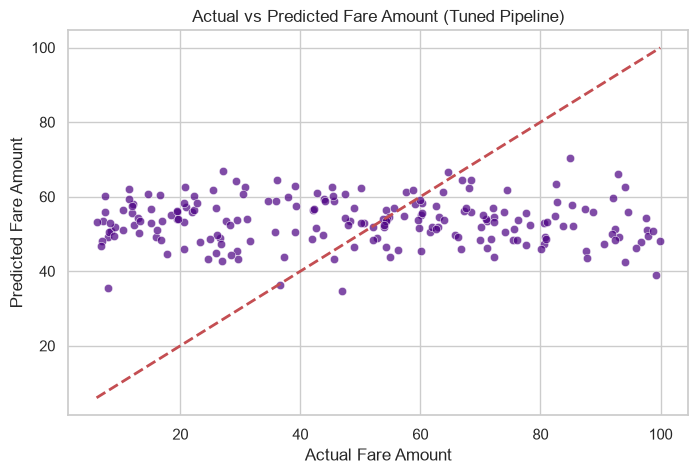

In [8]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📊 --- Final Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE)  : {mae:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R² Score                    : {r2:.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='indigo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Fare Amount')
plt.ylabel('Predicted Fare Amount')
plt.title('Actual vs Predicted Fare Amount (Tuned Pipeline)')
plt.show()

In [9]:
MODEL_FILENAME = 'final_fare_prediction_pipeline.pkl'
joblib.dump(best_model, MODEL_FILENAME)
print(f"📦 Model Artifact saved successfully as '{MODEL_FILENAME}'. Ready for deployment!")

📦 Model Artifact saved successfully as 'final_fare_prediction_pipeline.pkl'. Ready for deployment!
